# 📘 Insight 4.1: Learning & Skill Development Analysis

**Research Question:** How do learning methods correlate with experience level and technology adoption?

This notebook explores how developers learn at different stages of their careers and identifies which learning modalities predominantly drive the adoption of specific technologies.

### 🔧 Notebook Setup & Objectives
1.  **Data Prep:** Ensure learning method columns (`LearnCode`, `LearnCodeOnline`) are fully one-hot encoded.
2.  **Career Stage Analysis:** Visualize shifts in learning methods from Junior to Expert levels.
3.  **Advanced Technique (Correspondence Analysis):** Map the relationships between experience categories and learning preferences in 2D space.
4.  **Tech Adoption Links:** Identify which learning resources strongly correlate with specific high-growth technologies (e.g., Rust, AI tools).

In [3]:
# =========================================
# 1. IMPORTS & CONFIGURATION
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import prince  # For Correspondence Analysis (pip install prince if missing)
from scipy.stats import chi2_contingency

# Plot styling for appealing visuals
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
colors_so = ['#F48024', '#0A95FF', '#BBC0C4'] # Stack Overflow brand-ish colors

# Load Data
try:
    df = pd.read_csv('../data/processed/cleaned_full.csv', low_memory=False)
    print("✅ Data loaded successfully.")
except FileNotFoundError:
    print("❌ Error: 'cleaned_full.csv' not found. Check your data paths.")

✅ Data loaded successfully.


### 🛠️ 2. Local Data Preparation
We need to ensure the `LearnCode` and `LearnCodeOnline` multi-select questions are expanded into binary columns for this specific analysis.

In [4]:
def expand_multiselect_local(df, col_prefix, original_col):
    """Locally expands a multi-select column if not already done globally."""
    # Check if already expanded (look for at least 5 columns with the prefix)
    existing_cols = [c for c in df.columns if c.startswith(f"{col_prefix}_")]
    if len(existing_cols) > 5:
        print(f"ℹ️  {original_col} seems already expanded. Using existing columns.")
        return df, existing_cols
        
    print(f"🔄 Expanding {original_col}...")
    # Quick expansion logic
    df[original_col] = df[original_col].fillna('Unknown')
    all_options = set()
    for x in df[original_col].unique():
        all_options.update(str(x).split(';'))
    
    if '' in all_options: all_options.remove('')
    
    new_cols = []
    for option in all_options:
        clean_option = option.strip()
        col_name = f"{col_prefix}_{clean_option}"
        # Use highly efficient string contains for binary flag
        df[col_name] = df[original_col].str.contains(re.escape(clean_option), regex=True).astype(int)
        new_cols.append(col_name)
    
    return df, new_cols

# Expand standard learning methods
df, learn_cols = expand_multiselect_local(df, 'Learn', 'LearnCode')

# Expand online-specific resources
df, online_cols = expand_multiselect_local(df, 'Online', 'LearnCodeOnline')

# Filter for only valid experience categories
df_main = df[df['experience_category'].notna()].copy()

print(f"✅ Ready for analysis with {len(df_main):,} respondents.")

🔄 Expanding LearnCode...
🔄 Expanding LearnCodeOnline...
✅ Ready for analysis with 51,610 respondents.


--- 
## 📊 Analysis 1: Evolution of Learning Methods by Career Stage
How does the reliance on different learning resources change as a developer grows from Junior to Expert?

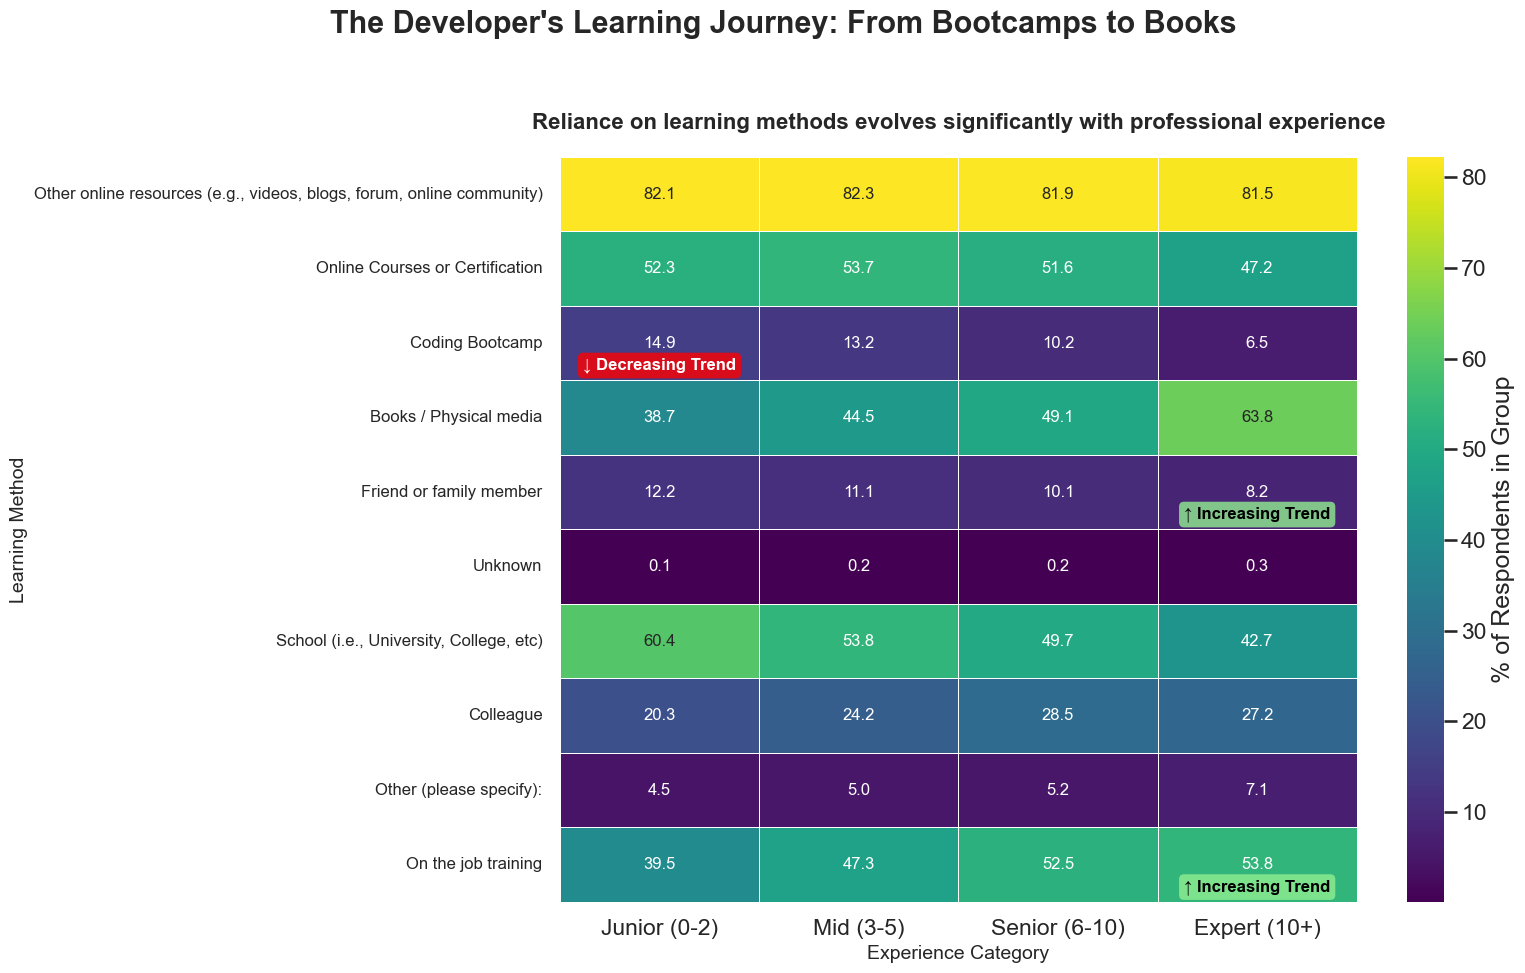

In [21]:
# =========================================
# VISUALIZATION 1: IMPROVED HEATMAP
# =========================================
# Aggregate data by experience category
exp_order = ['Junior (0-2)', 'Mid (3-5)', 'Senior (6-10)', 'Expert (10+)']
learn_agg = df_main.groupby('experience_category')[learn_cols].mean() * 100
learn_agg = learn_agg.reindex(exp_order)
learn_agg.columns = [c.replace('Learn_', '') for c in learn_agg.columns]

# --- Visualization ---
plt.figure(figsize=(16, 10))
heatmap = sns.heatmap(
    learn_agg.T,
    annot=True,
    fmt='.1f',
    cmap='viridis', # A more vibrant and accessible colormap
    linewidths=.5,
    annot_kws={"size": 12},
    cbar_kws={'label': '% of Respondents in Group'}
)

# Add a more descriptive title and subtitle
plt.suptitle("The Developer's Learning Journey: From Bootcamps to Books", fontsize=22, weight='bold')
plt.title("Reliance on learning methods evolves significantly with professional experience", fontsize=16, pad=20)

plt.ylabel('Learning Method', fontsize=14)
plt.xlabel('Experience Category', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(fontsize=12)

# Add annotations to highlight key trends
plt.text(0.5, 2.8, '↓ Decreasing Trend', ha='center', va='center', fontsize=12, color='white', weight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='red', ec='none', alpha=0.8))
plt.text(3.5, 4.8, '↑ Increasing Trend', ha='center', va='center', fontsize=12, color='black', weight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', ec='none', alpha=0.8))
plt.text(3.5, 9.8, '↑ Increasing Trend', ha='center', va='center', fontsize=12, color='black', weight='bold',
         bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', ec='none', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 💡 Insight 1 Observations:
*Experts with more than 10+ years of experiance tend to rely more on books for learning than compared to junior devs.*

---
## 🧠 Analysis 2: Advanced Correspondence Analysis (CA)
While the heatmap shows percentages, CA allows us to visualize the *association* between career stages and learning methods in a 2D perceptual map. Methods that plot closer to a specific experience category are more strongly associated with it than others.

C:\Users\Haris\AppData\Local\Temp\ipykernel_1984\3344959441.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(row_coords[0][i], row_coords[1][i], txt, fontsize=10, weight='bold', ha='center', va='center', color='Black')
C:\Users\Haris\AppData\Local\Temp\ipykernel_1984\3344959441.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(col_coords[0][i] + 0.01, col_coords[1][i], txt, fontsize=12, alpha=0.9, ha='left')


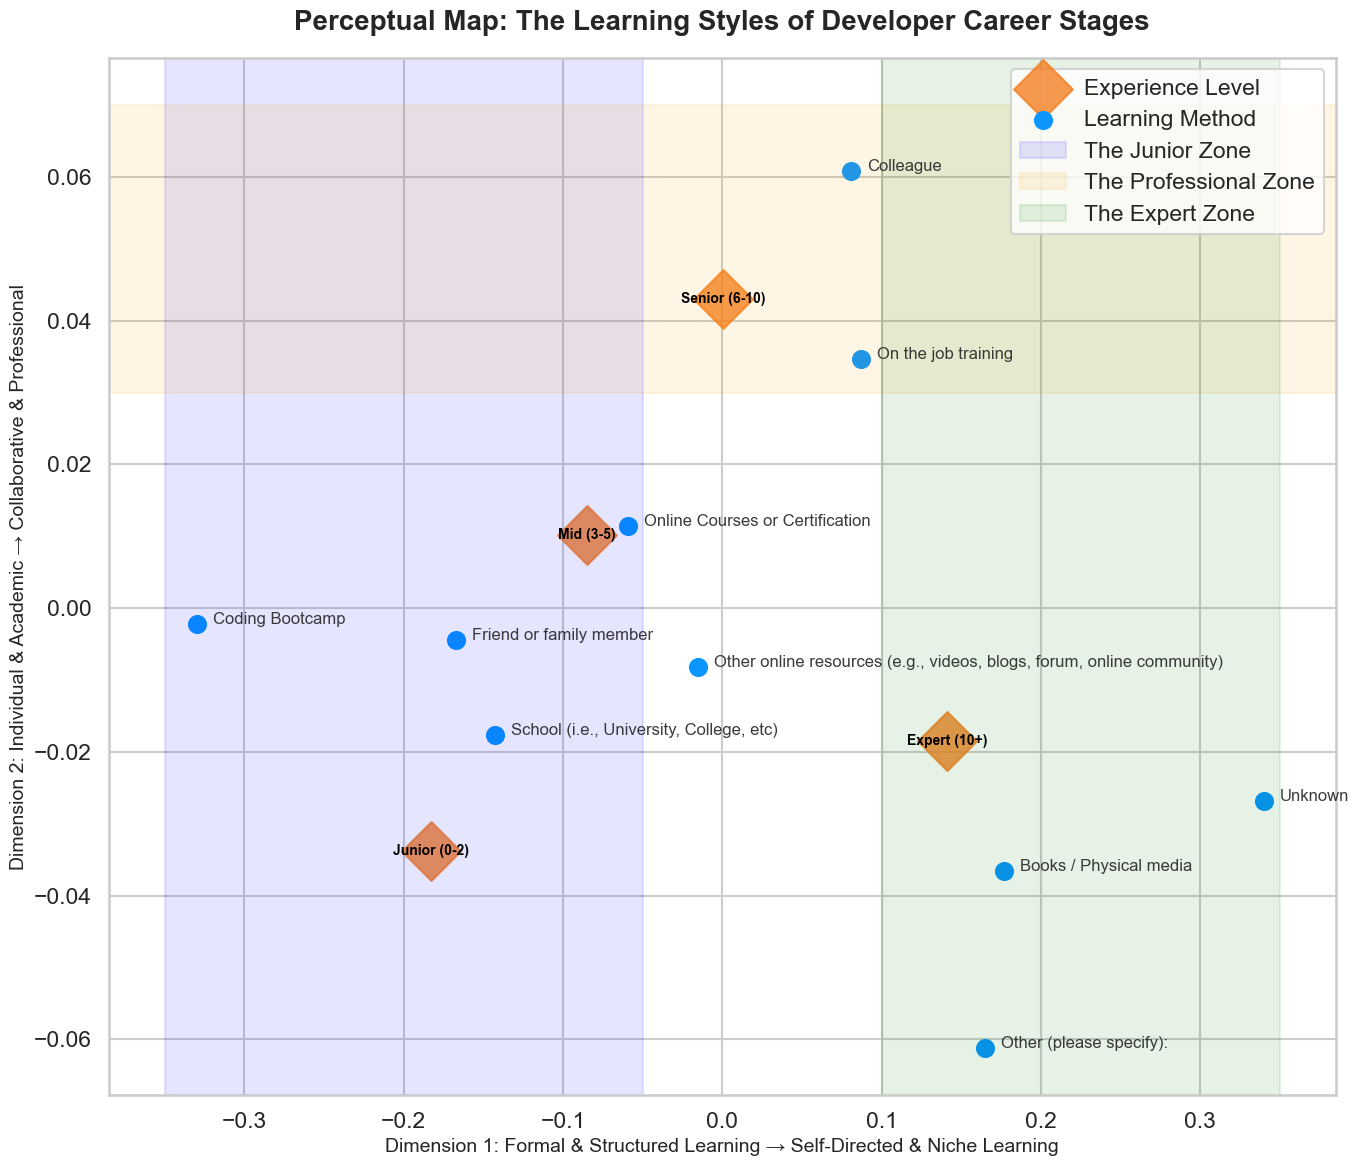

In [32]:
# =========================================
# VISUALIZATION 2: IMPROVED CORRESPONDENCE ANALYSIS
# =========================================
# (Assuming 'ca_table' is already created from your previous notebook cell)
ca = prince.CA(n_components=2, random_state=42).fit(ca_table)

# --- Custom Visualization ---
fig, ax = plt.subplots(figsize=(14, 12))

row_coords = ca.row_coordinates(ca_table)
col_coords = ca.column_coordinates(ca_table)

# Plot experience categories (rows)
ax.scatter(row_coords[0], row_coords[1], s=800, color='#F48024', label='Experience Level', marker='D', alpha=0.8)
for i, txt in enumerate(row_coords.index):
    ax.text(row_coords[0][i], row_coords[1][i], txt, fontsize=10, weight='bold', ha='center', va='center', color='Black')

# Plot learning methods (columns)
ax.scatter(col_coords[0], col_coords[1], s=150, color='#0A95FF', label='Learning Method', marker='o')
for i, txt in enumerate(col_coords.index):
    ax.text(col_coords[0][i] + 0.01, col_coords[1][i], txt, fontsize=12, alpha=0.9, ha='left')

# Add shaded zones
ax.axvspan(-0.35, -0.05, alpha=0.1, color='blue', label='The Junior Zone')
ax.axhspan(0.03, 0.07, alpha=0.1, color='orange', label='The Professional Zone')
ax.axvspan(0.1, 0.35, alpha=0.1, color='green', label='The Expert Zone')

ax.set_title("Perceptual Map: The Learning Styles of Developer Career Stages", fontsize=20, pad=20)
ax.set_xlabel("Dimension 1: Formal & Structured Learning → Self-Directed & Niche Learning", fontsize=14)
ax.set_ylabel("Dimension 2: Individual & Academic → Collaborative & Professional", fontsize=14)

ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

---
## 🚀 Analysis 3: Learning Pathways for Emerging Tech
Do people learn emerging technologies (like Rust or AI tools) differently than established ones (like Java)?

We will use **Association Analysis (Lift Score)** to find strong links. 

*Lift > 1.0 indicates a positive correlation (learning method X is more common among users of tech Y than the general population).*

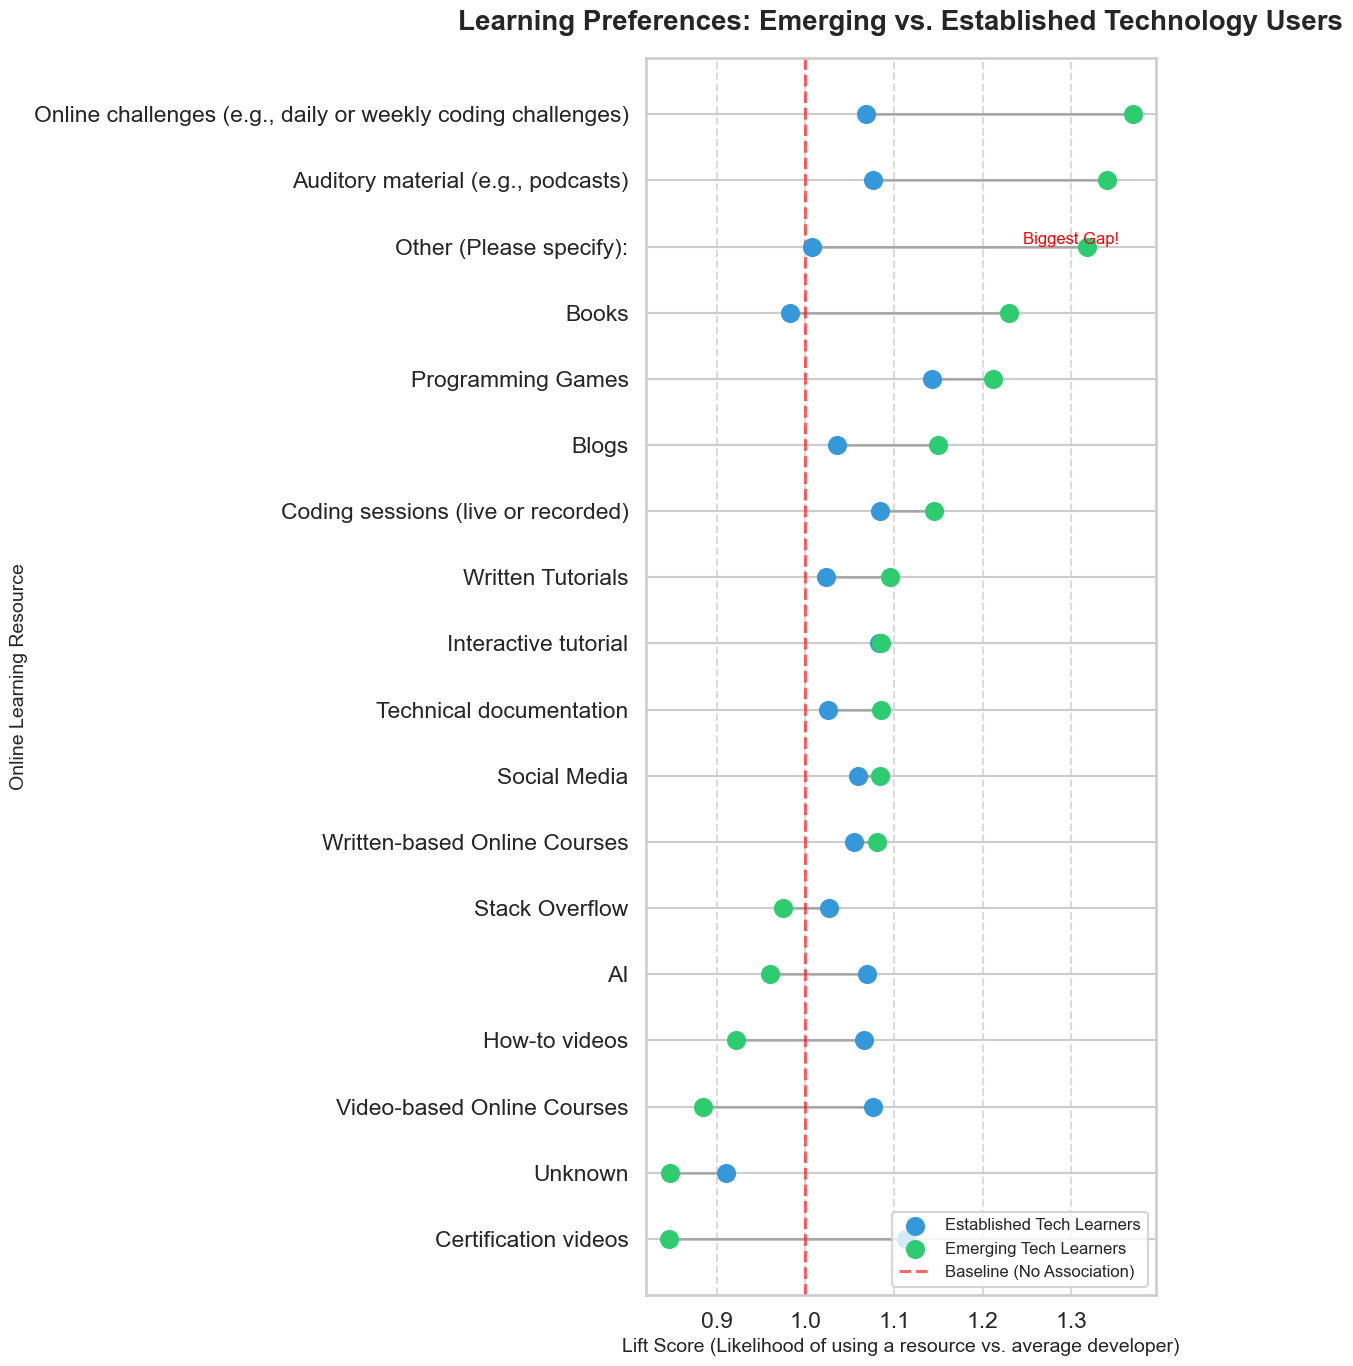

In [33]:
# =========================================
# VISUALIZATION 3: IMPROVED LIFT CHART (DUMBBELL PLOT)
# =========================================
# (Assuming df_lift is already created from your previous notebook cell)

# Pivot the data to have Emerging and Established side-by-side
df_pivot = df_lift.pivot_table(
    index='Learning Resource',
    columns='Tech Category',
    values='Lift Score'
).dropna().sort_values('Emerging', ascending=True)

# --- Visualization ---
fig, ax = plt.subplots(figsize=(12, 14))

# Create the "bar" of the dumbbell
ax.hlines(df_pivot.index, df_pivot['Established'], df_pivot['Emerging'], color='gray', alpha=0.5, linewidth=2)

# Create the dots
ax.scatter(df_pivot['Established'], df_pivot.index, color='#3498DB', s=150, label='Established Tech Learners', zorder=3)
ax.scatter(df_pivot['Emerging'], df_pivot.index, color='#2ECC71', s=150, label='Emerging Tech Learners', zorder=3)

# Add baseline and annotations
ax.axvline(1.0, color='red', linestyle='--', alpha=0.6, label='Baseline (No Association)')
ax.set_title("Learning Preferences: Emerging vs. Established Technology Users", fontsize=20, pad=20)
ax.set_xlabel("Lift Score (Likelihood of using a resource vs. average developer)", fontsize=14)
ax.set_ylabel("Online Learning Resource", fontsize=14)
ax.legend(fontsize=12, loc='lower right')

# Add labels for the largest gaps to tell a story
largest_gap_resource = (df_pivot['Emerging'] - df_pivot['Established']).abs().idxmax()
ax.text(1.3, largest_gap_resource, 'Biggest Gap!', ha='center', va='bottom', fontsize=12, color='red')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 🏁 Summary of Findings (4.1)

1.  **Career Evolution:** The data reveals a clear lifecycle of learning. Foundational methods like **"School"** and **"Coding Bootcamps"** decline sharply after the junior stage (from 60% and 15% respectively), while reliance on **"On the job training"** and **"Books"** steadily increases, with books being most popular among Experts (63.8%).

2.  **Distinct Learning Zones:** The Correspondence Analysis map identifies three distinct learning personas.
    *   **The Junior Zone:** Characterized by formal, structured learning (Bootcamps, School).
    *   **The Professional Zone:** Defined by collaborative, workplace learning (Colleagues, On the job training).
    *   **The Expert Zone:** Dominated by deep, self-directed, and niche learning (Books, Other specialized resources).

3.  **Tech Adoption Drivers:** Learning methods for new technologies are fundamentally different. Developers learning emerging tech are **~30% more likely to use online challenges and podcasts**, signaling a preference for hands-on, exploratory, and continuous learning to stay on the cutting edge.